## Simulazione fatta direttamente con numpy, stabilendo già partecipanti e vincitori alle auction, senza usare AuctionGym.

In [1]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [6]:
def group_data(dir_path: str) -> pd.DataFrame:
    """Return a DataFrame with the results of the simulation doing the average of the performance metrics over the runs and 
    grouping the results by Iteration. The function also computes the confidence interval for the metrics.

    Parameters
    ----------
    dir_path : str
        The path of the directory containing the results of the simulation.

    Returns
    -------
    pd.DataFrame
        A DataFrame with the results of the simulation grouped by Iteration.
    """
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            num_run = int(match.group(1))
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))
            
            curr_results = pd.read_csv(dir_path + file)

            curr_results['Run'] = num_run
            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha

            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['soglia_ctr','alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['impressions'])
    # intervallo di confidenza CTR e True CTR
    grouped_results['ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['ctr']
    grouped_results['ctr_ci'] = 1.96 * grouped_results['ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['ctr'])
    # publisher
    grouped_results['publisher_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['publisher']
    grouped_results['publisher_ci'] = 1.96 * grouped_results['publisher_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['publisher'])
    return grouped_results

In [33]:
def group_opt_data(dir_path: str) -> pd.DataFrame:
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'opt_exp_results_run_(\d+)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            num_run = float(match.group(1))
            
            curr_results = pd.read_csv(dir_path + file)

            curr_results['Run'] = num_run

            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['Run']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.mean()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.std()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.count()['clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.std()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.count()['impressions'])
    # intervallo di confidenza CTR e True CTR
    grouped_results['ctr_std'] = grouped_results_run_iter.std()['ctr']
    grouped_results['ctr_ci'] = 1.96 * grouped_results['ctr_std'] / np.sqrt(grouped_results_run_iter.count()['ctr'])
    # publisher
    grouped_results['publisher_std'] = grouped_results_run_iter.std()['publisher']
    grouped_results['publisher_ci'] = 1.96 * grouped_results['publisher_std'] / np.sqrt(grouped_results_run_iter.count()['publisher'])
    grouped_results = grouped_results.to_frame().T
    return grouped_results

In [138]:
def plot_clicks(ax, model_data, model):
    ax.plot(model_data['Iteration'].to_numpy(), model_data['clicks'].to_numpy(), label=f'{model}')
    if 'clicks_ci' in model_data.columns:
        ax.fill_between(model_data['Iteration'].to_numpy(), 
                        model_data['clicks'].to_numpy() -  model_data['clicks_ci'].to_numpy(), 
                        model_data['clicks'].to_numpy() +  model_data['clicks_ci'].to_numpy(), 
                        alpha=0.5)
    ax.grid(color="gray", linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    ax.set_ylabel('cl')
    ax.legend()

def plot_ctr(ax, model_data, model):
    ax.plot(model_data['Iteration'].to_numpy(), model_data['ctr'].to_numpy()*100, label=f'{model}')
    if 'ctr_ci' in model_data.columns:
        ax.fill_between(model_data['Iteration'].to_numpy(), 
                        (model_data['ctr'].to_numpy() -  model_data['ctr_ci'].to_numpy())*100, 
                        (model_data['ctr'].to_numpy() +  model_data['ctr_ci'].to_numpy())*100, 
                        alpha=0.5)
    ax.grid(color="gray", linestyle=(0, (10, 10)), linewidth=0.5, alpha=0.6)
    ax.set_ylabel('CTR %')
    ax.legend()
    
def plot_click_ctr(gr_res_models: dict, iteration: int = 1, save_path: str = None):
    """Plot on the same row two graphs: one with the clicks and one with the CTR.

    Parameters
    ----------
    gr_res_models : dict
        _description_
    iteration : int, optional
        _description_, by default 1
    target_ctr : float, optional
        _description_, by default 0.9
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

    for model, gr_res in gr_res_models.items():
        if model == 'opt':
            continue
        if 'ws' in gr_res.columns:
            for ws in gr_res['ws'].unique():
                model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['ws'] == ws)]
                iteration_list = model_data['Iteration'].to_numpy()
                target_ctr = model_data['soglia_ctr'].unique()[0]
                plot_clicks(ax1, model_data, f'{model} ws={ws}')
                plot_ctr(ax2, model_data, f'{model} ws={ws}')
                ax2.set_xlabel('t (time)')
        else:
            model_data = gr_res[(gr_res['Iteration']>iteration)]
            iteration_list = model_data['Iteration'].to_numpy()
            target_ctr = model_data['soglia_ctr'].unique()[0]
            plot_clicks(ax1, model_data, model)
            plot_ctr(ax2, model_data, model)
            ax2.set_xlabel('t (time)')

    opt_res = gr_res_models['opt']
    ax1.axhline(y=opt_res['clicks'].to_numpy(), color='r', linestyle='--', label=f'Optimal')
    if 'clicks_ci' in opt_res.columns:
        ax1.fill_between(iteration_list,
                        opt_res['clicks'].to_numpy() -  opt_res['clicks_ci'].to_numpy(), 
                        opt_res['clicks'].to_numpy() +  opt_res['clicks_ci'].to_numpy(), 
                        alpha=0.5)
    ax1.legend()
    # Target CTR
    ax2.axhline(y=target_ctr*100, color='r', linestyle='--', label=f'Target CTR')
    ax2.legend()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)
    plt.show()

### CTR = 67%

In [139]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_67_27_01_25/'
cucb_results = group_data(cucb_exp_dir)
cucb_opt_res = group_opt_data(cucb_exp_dir)

In [140]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_67_27_01_25/'
linucb_results = group_data(linucb_exp_dir)
linucb_opt_res = group_opt_data(linucb_exp_dir)

In [141]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

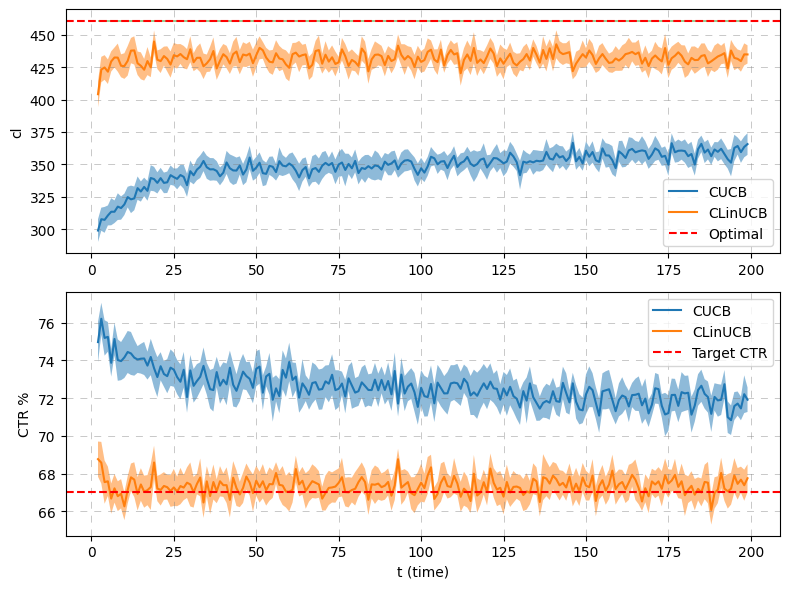

In [142]:
plot_click_ctr(models, iteration=1)

### CTR = 70%

In [143]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_7_27_01_25/'
cucb_results = group_data(cucb_exp_dir)
cucb_opt_res = group_opt_data(cucb_exp_dir)

In [144]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_7_27_01_25/'
linucb_results = group_data(linucb_exp_dir)
linucb_opt_res = group_opt_data(linucb_exp_dir)

In [146]:
models = {'CUCB': cucb_results, 'CLinUCB': linucb_results, 'opt': cucb_opt_res}

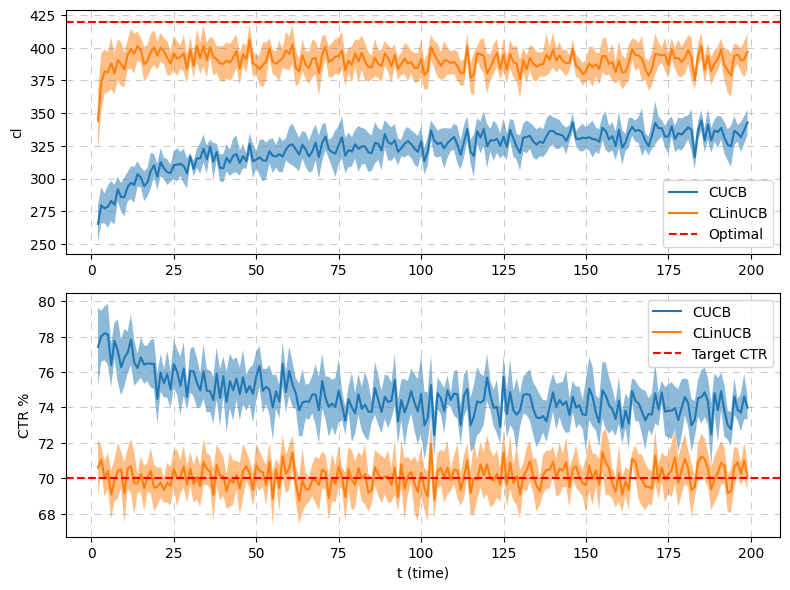

In [147]:
plot_click_ctr(models, iteration=1)

### CTR = 80%

In [148]:
cucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_cucb_ctr_0_8_27_01_25/'
cucb_results = group_data(cucb_exp_dir)
cucb_opt_res = group_opt_data(cucb_exp_dir)

In [149]:
linucb_exp_dir = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_8_27_01_25/'
linucb_results = group_data(linucb_exp_dir)
linucb_opt_res = group_opt_data(linucb_exp_dir)

In [150]:
models = {
    'CUCB': cucb_results, 
    'CLinUCB': linucb_results, 
    'opt': linucb_opt_res
}

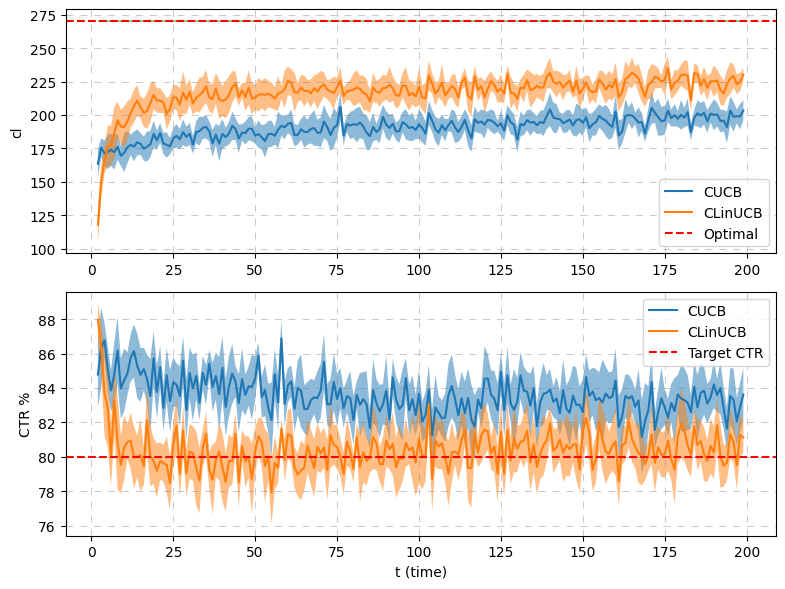

In [151]:
plot_click_ctr(models, iteration=1)